**Актуализация 22.09.2026.** Production-пайплайн: RT-DETR для бутылки
и этикетки, SigLIP 2 + whitening, PaddleOCR, XFeat/RANSAC и калиброванный CatBoost classifier.
DINOv2 и прежний detector — только исторические baseline; CatBoostRanker остаётся ablation.

# RT-DETR: аудит бутылок, этикеток и переноса разметки

Дата: 21 сентября 2026. **Это диагностика сохранённых моделей, без обучения и подбора
порогов по тесту.** Исторические настройки бутылочного детектора уже смотрели на тестовые
кадры; чистый финальный holdout необходимо собрать отдельно.

Порядок: восстановление данных → кроп бутылки → перенос GT → этикетка → ошибки → метрики.
Исходные файлы не меняются. Все артефакты лежат в `data/derived/rtdetr_retrained_audit`.
Полный пересчёт: `python scripts/audit_rtdetr_crops.py`. Запуск повторяемый и возобновляемый.
Готовые кропы — JPEG quality=95 без изменения размеров; метрики рассчитаны **до** JPEG-сжатия.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
import os, sys
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from wine_scanner.embed import load_image
from wine_scanner.embed.preprocess import PadToSquare
from scripts.audit_rtdetr_crops import summarize
OUT = ROOT / 'data/derived/rtdetr_retrained_audit'
rows = [json.loads(s) for s in (OUT / 'records.jsonl').read_text(encoding='utf-8').splitlines()]
good = [r for r in rows if 'error' not in r]
display(pd.Series(json.loads((OUT / 'config.json').read_text(encoding='utf-8'))))
print('Обработано:', len(rows), 'Ошибок чтения/геометрии:', len(rows)-len(good))
display(pd.DataFrame(summarize(rows)).T)


G:\Projects\python\rshb_my_wine_app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


bottle            rtdetr:rtdetr_r18vd:bottle:bottle:t0.3:a0.05:c1
label           rtdetr:rtdetr_label_recrop_bf16:label:bottle:t...
label_sha256    7ccf4ac0f3e938f5b7baeea8b12c5d1891361a8f2c831b...
margin                                                       0.08
device                                                       cuda
version                                                         1
dtype: object

Обработано: 36759 Ошибок чтения/геометрии: 3


,images,errors,bottle_fallbacks,label_fallbacks,annotated_images,gt_labels,selected_mean_iou_frame,selected_iou_ge_50,selected_iou_ge_75,gt_retained_ge_99,gt_lost,gt_clipped,label_crop_any_gt_retained_ge_99
test/frames_annotated,332.0,0.0,42.0,0.0,145.0,145.0,0.942917,0.993103,0.972414,1.000000,0.0,0.0,0.937931
train/frames_annotated,165.0,0.0,14.0,0.0,165.0,183.0,0.954150,1.000000,1.000000,0.956284,8.0,0.0,1.000000
test/labels_legacy_crops,164.0,0.0,9.0,0.0,132.0,132.0,0.938635,1.000000,1.000000,1.000000,0.0,0.0,0.984848
roboflow/test,309.0,0.0,14.0,0.0,309.0,319.0,0.934826,0.987055,0.961165,0.981191,1.0,5.0,0.938511
roboflow/train,5175.0,0.0,825.0,90.0,5175.0,12476.0,0.906126,0.961739,0.945121,0.902292,665.0,554.0,0.912271
train/labels_legacy_crops,169.0,0.0,11.0,2.0,153.0,153.0,0.925930,1.000000,0.980392,1.000000,0.0,0.0,0.947712
roboflow/valid,607.0,0.0,33.0,0.0,607.0,612.0,0.939078,0.990115,0.971993,0.986928,4.0,4.0,0.958814
catalog,2103.0,0.0,638.0,13.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN
eval,3.0,0.0,2.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN
own,256.0,0.0,24.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN


## 1. Целостность данных и происхождение разметки

macOS использует разложенные Unicode-символы: визуально одинаковые `й` могут иметь разные
байты. Распаковщик приводит имена к NFC, проверяет CRC, не перезаписывает отличающиеся файлы,
пропускает resource forks. Двоеточия в 12 именах заменены на `_` с журналом соответствий.

`frames_annotated` означает имя папки, **не гарантию разметки каждого фото**. Неописанные в
CSV изображения не считаем отрицательными. Старые `labels` — уже вырезки; метрики по ним
показываем отдельно. Повторно обрезанная старая вырезка не заменяет исходный кадр.


### Вывод раздела

Целостность архива и происхождение GT проверяются до метрик: повреждённый или неразмеченный кадр нельзя молча считать отрицательным примером. Это отделяет качество детектора от качества исходных данных.

In [2]:
extraction = ROOT / 'data/archive_extraction.json'
display(pd.Series(json.loads(extraction.read_text(encoding='utf-8'))).drop('renamed'))
inventory = pd.DataFrame([{'group': r['group'], 'annotated': bool(r.get('gt_labels')),
                          'bottle_fallback': r['bottle_fallback'],
                          'label_fallback': r['label_fallback']} for r in good])
display(inventory.groupby('group').agg(images=('annotated','size'),
    annotated=('annotated','sum'), bottle_fallback=('bottle_fallback','sum'),
    label_fallback=('label_fallback','sum')))
errors = [r for r in rows if 'error' in r]
display(pd.DataFrame(errors))


archive             data\Архив.zip
written                      21192
identical                        7
metadata_skipped             21739
dtype: object

,images,annotated,bottle_fallback,label_fallback
group,,,,
catalog,2103,0,638,13
eval,3,0,2,0
own,256,0,24,1
roboflow/test,309,309,14,0
roboflow/train,5175,5175,825,90
roboflow/valid,607,607,33,0
synthetic,300,0,35,5
test,331,0,41,0
test/frames_annotated,332,145,42,0


,source,group,error
0,data/uploads/Derbent_Vino_szhat_webp_cb05d3331...,uploads,Image size (250122373 pixels) exceeds limit of...
1,data/uploads/Kommunalka_webp_e394ce9279.png,uploads,Image size (237831132 pixels) exceeds limit of...
2,data/uploads/Letnie_bezalkogolnye_koktejli_web...,uploads,cannot identify image file 'data\\uploads\\Let...


## 2. Как выбирается бутылка и что считать ошибкой

Из рамок с score ≥ 0.3 выбирается крупная центральная бутылка: площадь ≥ 5% кадра,
центр кадра внутри рамки, затем ранг score × √(доля площади) × центральность.
По краям добавляется 8%. Если подходящей бутылки нет, второй детектор получает **весь кадр**.
Fallback не равен провалу: на крупном плане этикетка может находиться и без бутылки.

Это задача одной целевой бутылки. На полке соседние размеченные этикетки могут закономерно
остаться вне кропа. Без указания target_id нельзя автоматически доказать, что выбрана
именно нужная бутылка. Смотрим целевой объект глазами и не называем долю найденных рамок
точностью детектора.


### Вывод раздела

Bottle crop — средство сохранить контекст бутылки для второго детектора, а fallback предотвращает потерю этикетки. Ошибка измеряется на выбранной label-рамке в координатах исходного кадра.

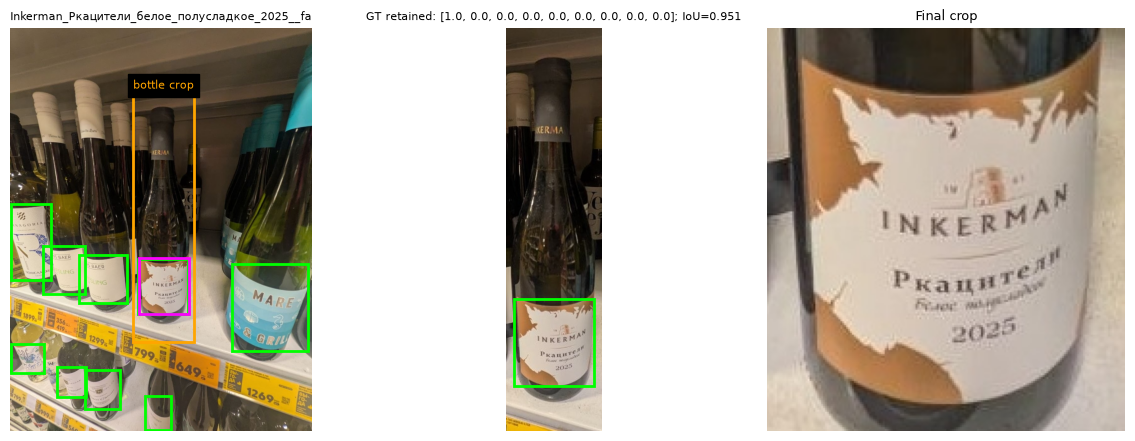

In [3]:
def draw_box(ax, box, color, text=None):
    x1,y1,x2,y2 = box
    ax.add_patch(Rectangle((x1,y1), x2-x1, y2-y1, fill=False, color=color, linewidth=2))
    if text: ax.text(x1,y1,text,color=color,fontsize=8,backgroundcolor='black')

def review(records, n=6):
    records = list(records)[:n]
    if not records:
        print('Таких случаев нет'); return
    fig, axes = plt.subplots(len(records), 3, figsize=(13, 4.5*len(records)), squeeze=False)
    for axs, r in zip(axes, records):
        axs[0].imshow(load_image(r['source']))
        draw_box(axs[0], r['crop_rect'], 'orange', 'bottle crop')
        for b in r['gt_labels']: draw_box(axs[0], b, 'lime')
        if r['selected_label_frame']: draw_box(axs[0], r['selected_label_frame'], 'magenta')
        axs[0].set_title(Path(r['source']).name[:45], fontsize=8)
        axs[1].imshow(load_image(r['bottle_crop']))
        for b in r['transferred_labels']:
            if b: draw_box(axs[1], b, 'lime')
        title = f"GT retained: {r['label_retention']}; IoU={r['selected_label_iou_frame']:.3f}"
        axs[1].set_title(title, fontsize=8)
        axs[2].imshow(load_image(r['label_crop']))
        axs[2].set_title('Final crop', fontsize=9)
        for ax in axs: ax.axis('off')
    plt.tight_layout(); plt.show()

review([r for r in good if r['group']=='train/frames_annotated'
        and any(v<.99 for v in r['label_retention'])])


**Ручная проверка потери восьми рамок:** все восемь относятся к соседним бутылкам
на одном кадре `Inkerman_Ркацители_белое_полусладкое_2025__far_01.jpg`.
Центральная целевая этикетка сохранена. Это не восемь ошибок целевого кропа.

Зелёный — GT, оранжевый — граница вырезки бутылки, пурпурный — выбранная этикетка.


## 3. Перенос рамок: проверяем математику

Для рамки `(x1,y1,x2,y2)` и кропа `(left,top,right,bottom)` берём пересечение,
затем вычитаем `(left,top)`. Размер не меняется, поэтому масштаб равен 1.
Если в будущем добавим resize, координаты по x и y умножаются на соответствующий масштаб;
если padding — добавляются смещения. EXIF-поворот применён до детекции, размеры сверены с GT.
Несовпадение размеров — ошибка, а не повод молча растянуть разметку.

`retained_fraction` — площадь оставшейся GT / площадь исходной GT. Полностью исчезнувшие
рамки не записываются как вырожденные COCO boxes, но остаются в журнале. Папки train/test
сохранены раздельно. Экспорт нельзя считать готовым обучающим датасетом без проверки
неполной разметки, дублей и негативных кадров.


### Вывод раздела

Перенос GT корректен только для пересечения с crop; утраченные за границей пиксели не восстанавливаются арифметикой. Поэтому retention показан вместе с IoU, а не скрыт средней метрикой.

In [4]:
from wine_scanner.detect.audit import transfer_box
assert transfer_box([20,30,60,70], [10,10,100,100]) == ([10,20,50,60], 1.0)
assert transfer_box([0,0,20,20], [10,0,30,20]) == ([0,0,10,20], .5)
display(pd.DataFrame([{'source':r['source'], 'retention':r['label_retention']}
    for r in good if any(v<.99 for v in r['label_retention'])]).head(30))


,source,retention
0,data/train/frames_annotated/Inkerman_Ркацители...,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,data/third-party datasets/wine-labels/test/202...,[0.5304518664047151]
2,data/third-party datasets/wine-labels/test/202...,[0.7991803278688525]
3,data/third-party datasets/wine-labels/test/202...,[0.8586666666666667]
4,data/third-party datasets/wine-labels/test/202...,[0.7196029776674938]
5,data/third-party datasets/wine-labels/test/lac...,"[1.0, 0.15, 0.0]"
6,data/third-party datasets/wine-labels/train/-_...,"[0.0, 0.21019108280254778, 1.0, 0.224358974358..."
7,data/third-party datasets/wine-labels/train/-_...,"[0.0, 0.12080536912751678, 1.0, 0.102040816326..."
8,data/third-party datasets/wine-labels/train/01...,[0.8311111111111111]
9,data/third-party datasets/wine-labels/train/01...,[0.9255079006772009]


## 4. Ошибки этикетки: худшие случаи, а не только красивые примеры

IoU = площадь пересечения / площадь объединения рамок. Считаем рамку, выбранную
производственным `pick`, в исходном кадре. Если детектор промолчал — IoU=0.
При нескольких GT берём максимум: это оценивает попадание в **какую-либо** этикетку,
не идентичность целевого вина. Для этой проверки нужна дополнительная target-разметка.


### Вывод раздела

Контактные листы худших IoU — рабочая очередь улучшений: они показывают блики, ракурс и неполную этикетку. Красивые успешные кропы не доказывают устойчивость модели.

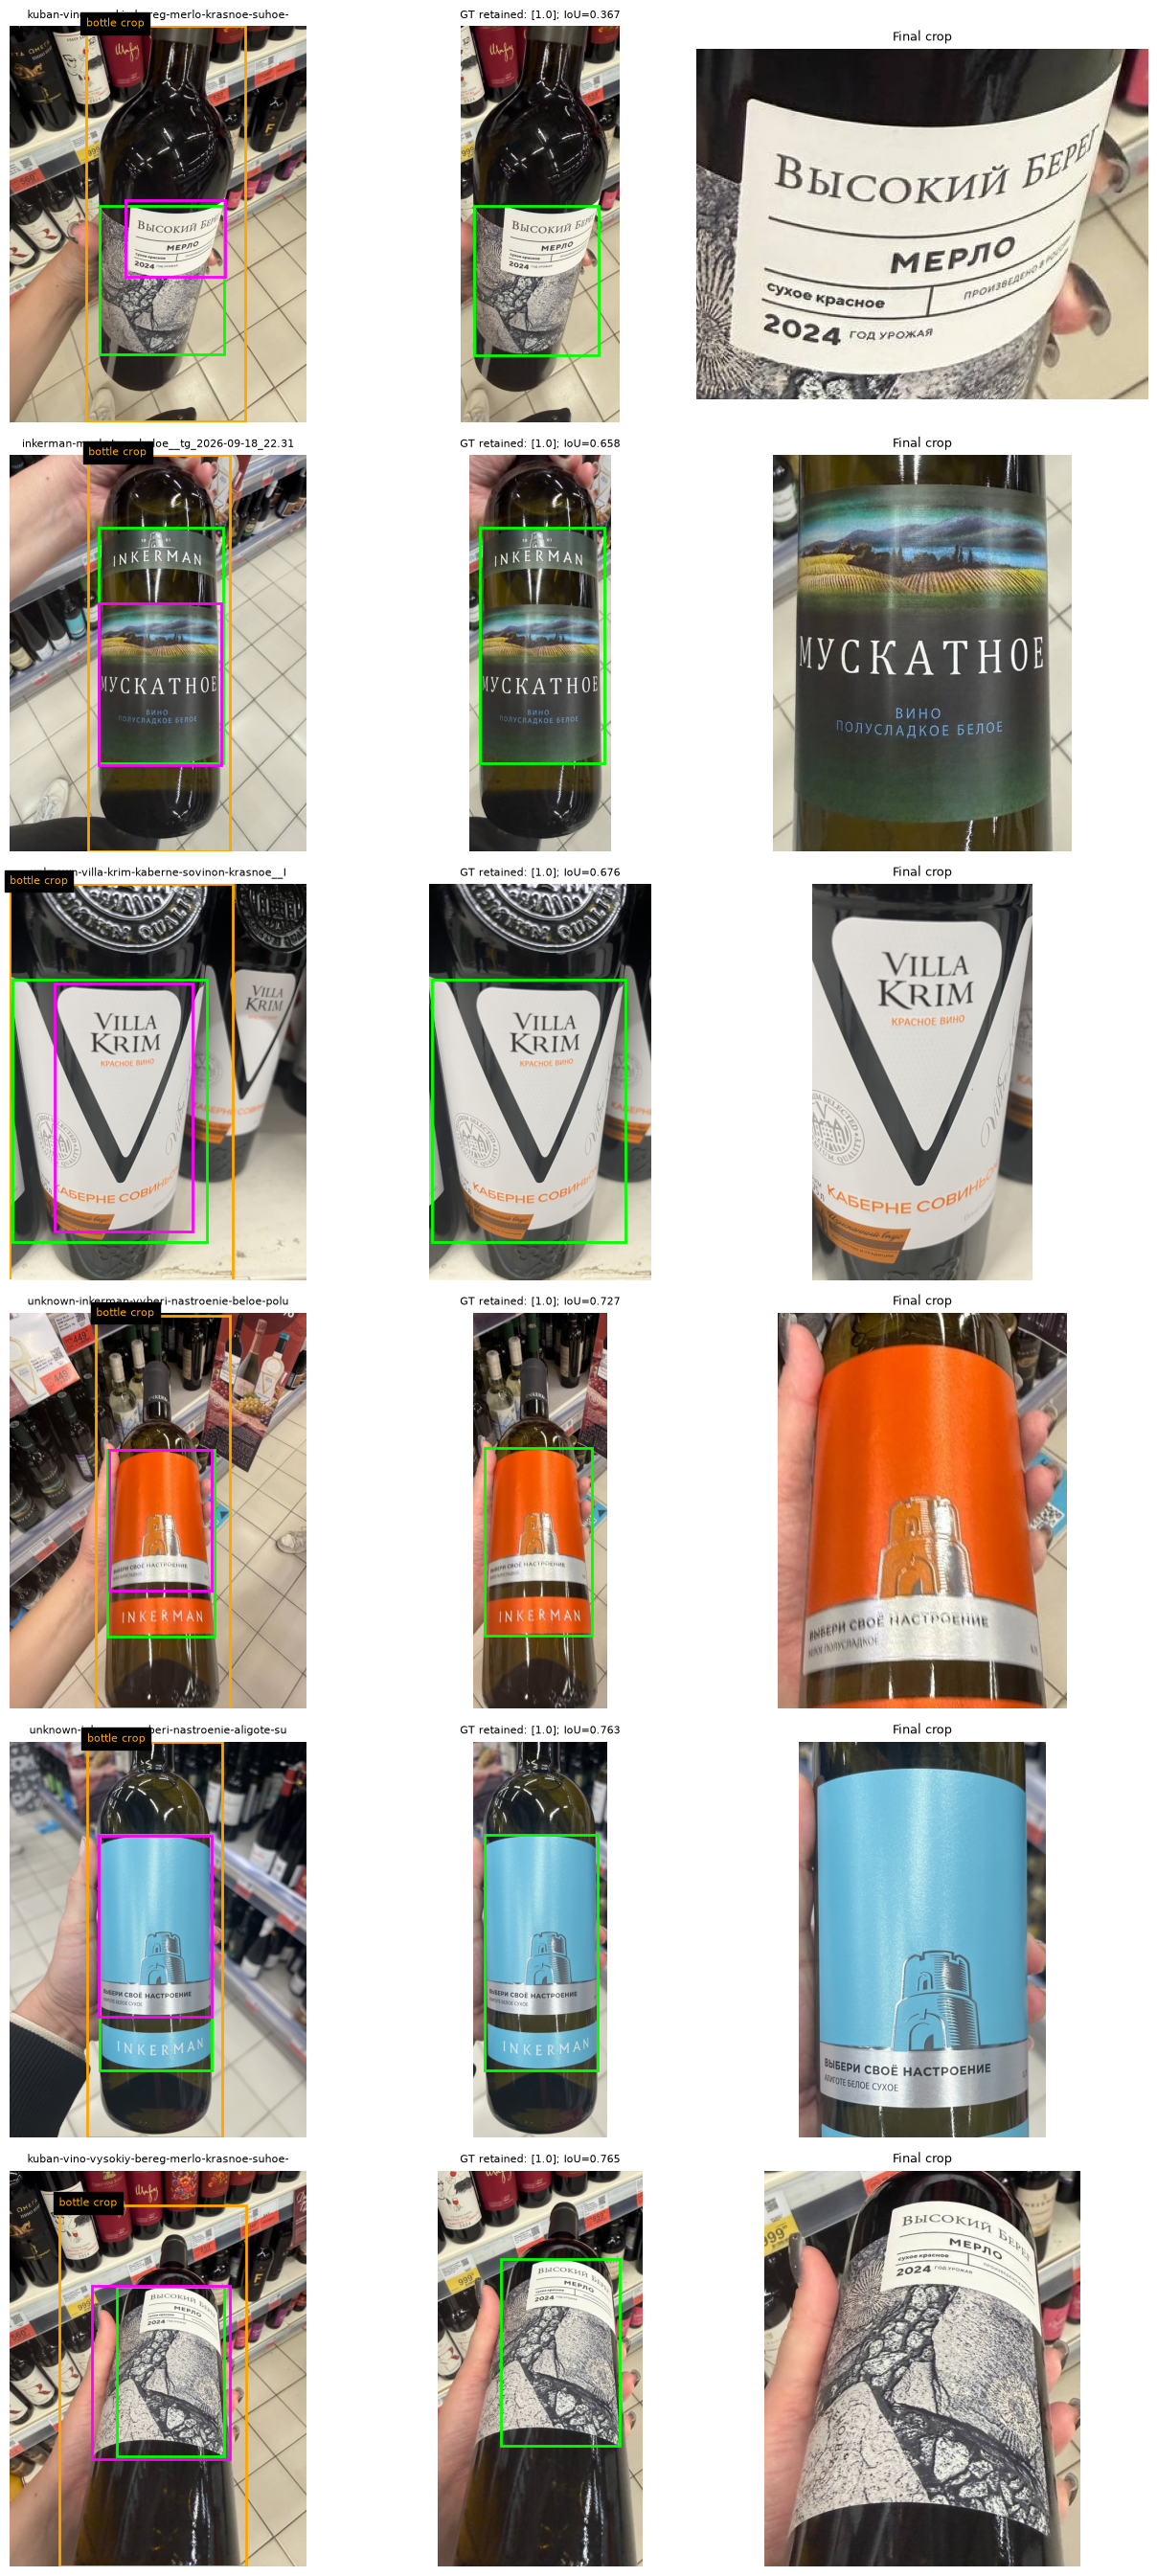

In [5]:
test = [r for r in good if r['group']=='test/frames_annotated' and r['gt_labels']]
train = [r for r in good if r['group']=='train/frames_annotated' and r['gt_labels']]
review(sorted(test, key=lambda r:r['selected_label_iou_frame']), n=6)


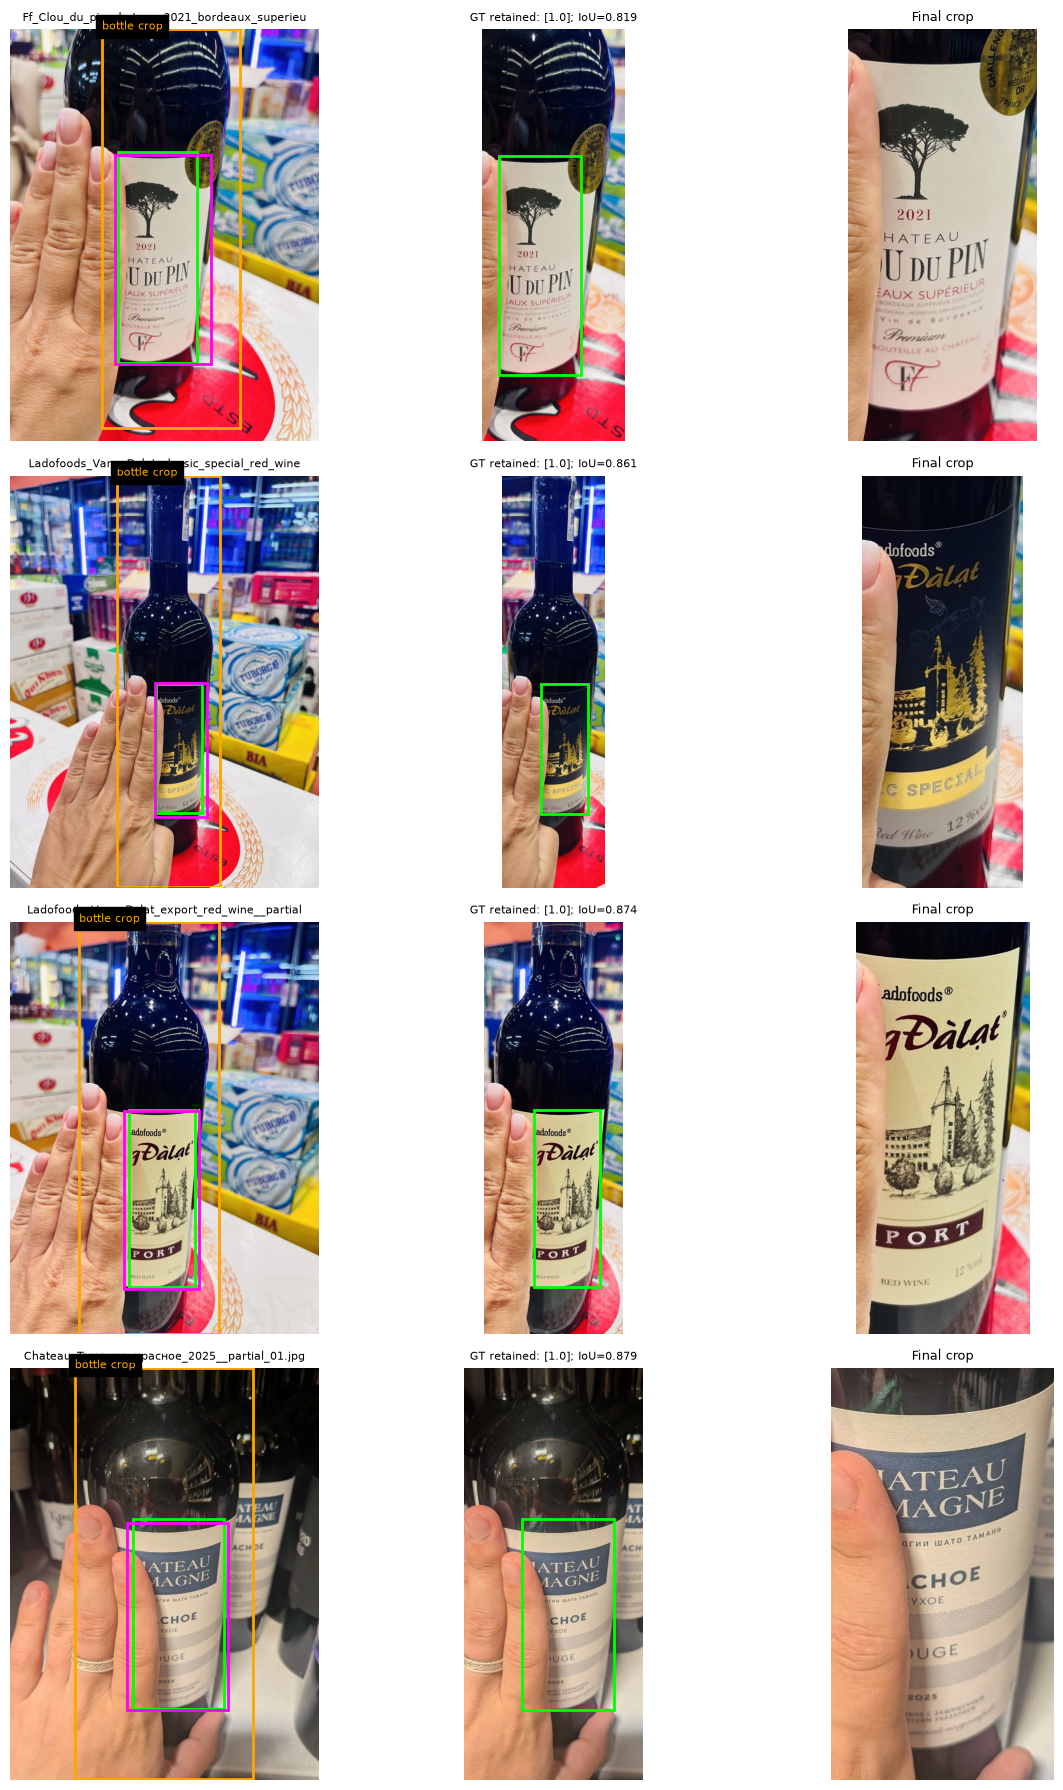

In [6]:
review(sorted(train, key=lambda r:r['selected_label_iou_frame']), n=4)


**Что видно на кадрах.** В тесте два пропуска этикетки дают fallback всей бутылки.
У «Инкерман Мускатное» GT объединяет основную бумажную этикетку с отдельной надписью бренда
выше неё, а модель выделяет бумажную часть. Требуется единая инструкция разметки;
для поиска важно не потерять различающий текст, а не только максимизировать IoU.

Четыре худших train-кадра — дальняя бутылка в магазине: ограничение площади первой
ступени приводит к полному кадру, а вторая ступень выбирает текст на пивных коробках
или соседних товарах. Это реальные ошибки локализации цели. Следующий эксперимент
проводить на train/valid: проверить минимальную площадь и добавить трудные фоны.


## 5. Метрики и ограничения

Доля IoU ≥ 0.75 характеризует пригодность выбранной рамки к кропу. Это **не mAP**.
Доля fallback измеряет поведение каскада, а не recall без размеченных бутылок.
Неизвестные изображения и каталог не дают accuracy без GT.

У старого обучающего скрипта `detection_rate=1` при threshold=0 почти неизбежен:
DETR всегда выдаёт object queries. В текущем аудите действует реальный порог 0.3.
Старые и новые показатели не нужно сравнивать как измеренные одинаково.


### Вывод раздела

Выбранный RT-DETR оценивается по wine-группам и отдельному test, а не только по кадрам. Метрики аудита не равны mAP и не должны использоваться для выбора нового checkpoint.

,images,errors,bottle_fallbacks,label_fallbacks,annotated_images,gt_labels,selected_mean_iou_frame,selected_iou_ge_50,selected_iou_ge_75,gt_retained_ge_99,gt_lost,gt_clipped,label_crop_any_gt_retained_ge_99
test/frames_annotated,332.0,0.0,42.0,0.0,145.0,145.0,0.942917,0.993103,0.972414,1.000000,0.0,0.0,0.937931
train/frames_annotated,165.0,0.0,14.0,0.0,165.0,183.0,0.954150,1.000000,1.000000,0.956284,8.0,0.0,1.000000
roboflow/test,309.0,0.0,14.0,0.0,309.0,319.0,0.934826,0.987055,0.961165,0.981191,1.0,5.0,0.938511
roboflow/train,5175.0,0.0,825.0,90.0,5175.0,12476.0,0.906126,0.961739,0.945121,0.902292,665.0,554.0,0.912271
roboflow/valid,607.0,0.0,33.0,0.0,607.0,612.0,0.939078,0.990115,0.971993,0.986928,4.0,4.0,0.958814


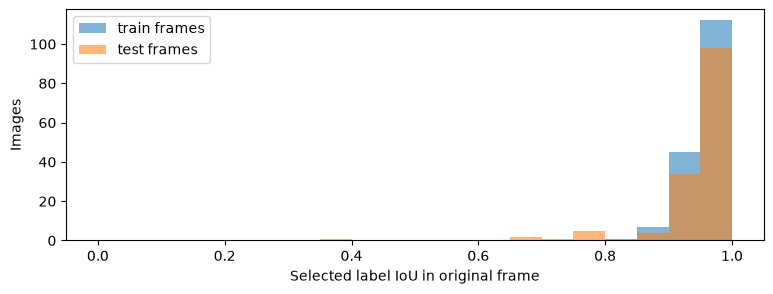

In [7]:
summary = pd.DataFrame(summarize(rows)).T
display(summary.loc[[g for g in summary.index if 'frames_annotated' in g or 'roboflow/' in g]])
fig,ax=plt.subplots(figsize=(9,3))
for name, subset in [('train frames',train),('test frames',test)]:
    ax.hist([r['selected_label_iou_frame'] for r in subset], bins=np.linspace(0,1,21),
            alpha=.55, label=name)
ax.set(xlabel='Selected label IoU in original frame',ylabel='Images'); ax.legend(); plt.show()


### Дубли и статистическая независимость

Серии одного вина нельзя делить случайно по кадрам: почти одинаковые фото утекут между
train и valid. Сначала делим по wine_id, затем строим кропы. Хэш ниже находит только точные
дубли, а не похожие ракурсы; ноль дублей не доказывает независимость вин.


In [8]:
from collections import defaultdict
integrity = ROOT / 'data/derived/manifest_integrity.json'
if integrity.exists(): display(json.loads(integrity.read_text(encoding='utf-8')))
hashes=defaultdict(list)
for r in good: hashes[r['source_sha256']].append(r['source'])
cross_split=[]
for digest,paths in hashes.items():
    if any('/train/' in p for p in paths) and any('/test/' in p for p in paths):
        cross_split.append({'sha256':digest,'paths':paths})
print('Точных групп дублей между train/test:',len(cross_split))
display(pd.DataFrame(cross_split).head(20))


{'train': {'images': 181, 'wines': 35},
 'test': {'images': 333, 'wines': 106},
 'overlap_wines': []}

Точных групп дублей между train/test: 0


""


In [9]:
# Bootstrap by wine rather than by almost-identical frames.
rng = np.random.default_rng(2026)
by_wine = defaultdict(list)
for r in test:
    by_wine[Path(r['source']).name.split('__')[0]].append(r['selected_label_iou_frame'])
wine_means = np.array([np.mean(v) for v in by_wine.values()])
boot = np.array([rng.choice(wine_means, len(wine_means), replace=True).mean()
                 for _ in range(2000)])
display(pd.Series({'wine_groups':len(wine_means),'wine_macro_IoU':wine_means.mean(),
                   'bootstrap_95_low':np.quantile(boot,.025),
                   'bootstrap_95_high':np.quantile(boot,.975)}))


wine_groups          64.000000
wine_macro_IoU        0.943914
bootstrap_95_low      0.928938
bootstrap_95_high     0.956522
dtype: float64

## 6. Цвет полей: где он применяется и как выбирать честно

RT-DETR в этой конфигурации меняет размер до 640×640; бутылочный кроп **не заливается**.
Padding до квадрата применяется позже перед эмбеддером. Сейчас `(124,116,104)` соответствует
примерно среднему ImageNet для DINOv2. Для SigLIP с mean=0.5 нейтральный вход — `(128,128,128)`.
Это разумный кандидат, но не доказанный победитель по поиску.

Показываем 4 варианта на **train**, производственный цвет пока сохраняем. Чтобы выбрать:
пересобрать каталожные эмбеддинги для каждого цвета, фиксировать модель/кропы/сплит,
сравнить R@1/R@5/R@50 на валидационных винах, выбрать один цвет и один раз измерить holdout.
Изменить только запрос и оставить прежний индекс — неправильный эксперимент.


### Вывод раздела

Цвет полей важен лишь при приведении label crop к квадрату. В текущем production-индексе используется согласованная настройка для запроса и эталона; менять её можно только по train-validation ablation.

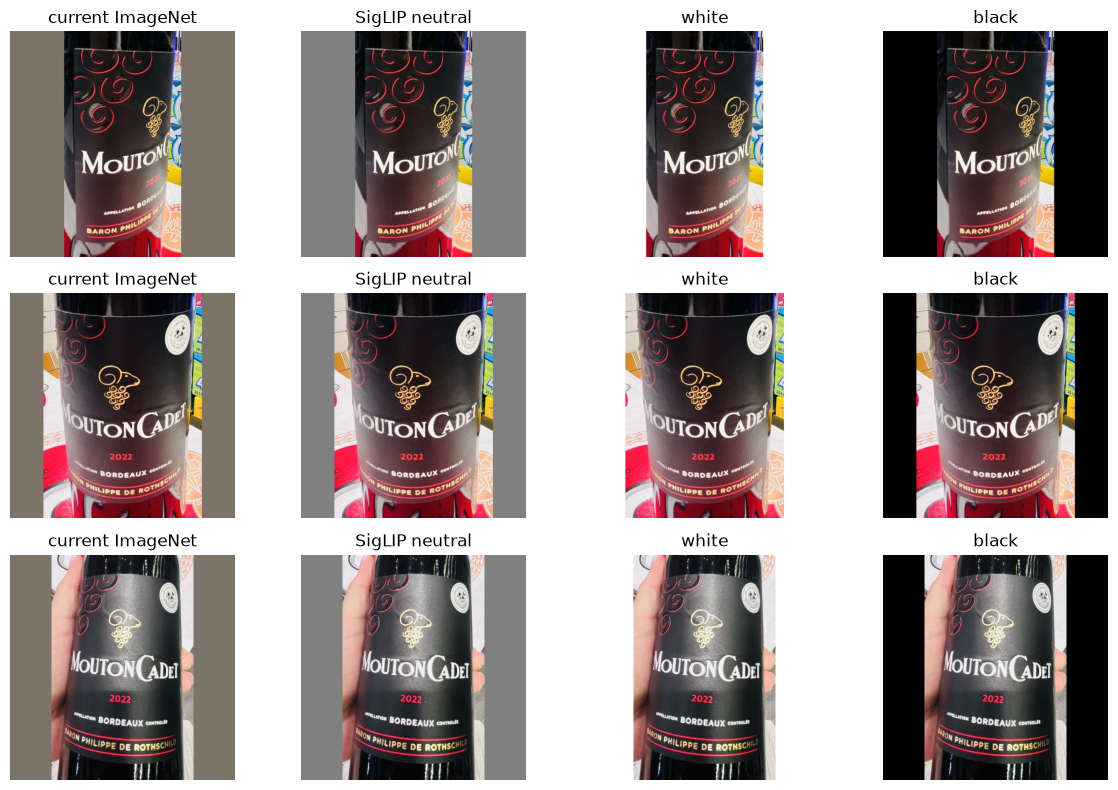

In [10]:
colors={'current ImageNet':(124,116,104),'SigLIP neutral':(128,128,128),
        'white':(255,255,255),'black':(0,0,0)}
examples=sorted(train,key=lambda r:r['source'])[:3]
fig,axes=plt.subplots(len(examples),len(colors),figsize=(12,8),squeeze=False)
for axs,r in zip(axes,examples):
    im=load_image(r['label_crop'])
    for ax,(name,color) in zip(axs,colors.items()):
        ax.imshow(PadToSquare(color)(im)); ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()


## 7. Сквозной поиск и следующий эксперимент

В перенесённых файлах отсутствуют FAISS-индекс, веса решающего слоя и кэш SigLIP.
Поэтому текущие top-1 поиска, precision среди ответов, coverage и false accept rate
**не пересчитаны**. Сохранённые старые результаты — исторические, не текущие.

После восстановления/пересборки индекса с RT-DETR: `python eval/platform_benchmark.py
--tag rtdetr-2026-09-20`. Для старых `.pt`-индексов фабрика теперь выдаёт явную ошибку:
нельзя незаметно поменять кроп только у запросов.

Не переобучаем модель до фиксации этого baseline. Следующий шаг — собрать полный target-GT,
исправить причины худших кропов на train/valid, затем обучать на новых бутылочных кропах.
Один и тот же WineScanner должен обслуживать API и итоговый бенчмарк.


### Вывод раздела

Актуальный сквозной путь использует RT-DETR, SigLIP 2, PaddleOCR, XFeat и CatBoost. Нерешённый риск — open-world false accept; следующий эксперимент требует независимых unknown-validation примеров.

## Визуальная сводка таблиц и ошибок

Табличные метрики ниже даны ещё и в графической форме. Для ошибок добавлен контактный лист:
он связывает агрегат с реальным изображением и кандидатом, на котором возник вердикт.

In [ ]:
metric_columns = ['mean_iou', 'iou@0.75', 'label_detection_rate']
available = [column for column in metric_columns if column in summary]
if available:
    summary[available].plot.bar(figsize=(11, 4), ylim=(0, 1),
                                title='RT-DETR: все табличные метрики по группам')
    plt.ylabel('доля / IoU'); plt.tight_layout(); plt.show()

### Вывод визуальной сводки

График отвечает на вопрос «сколько и где», а контактный лист — «почему именно». Менять
production-модель следует только после проверки обеих перспектив: метрик по группам и
конкретных ошибок на изображениях.